# FASE 4: ANALISIS DATA EKSPLORATIF (EDA)
Fase ini mengeksplorasi data yang telah diperkaya di tahap sebelumnya melalui metode visualisasi.
Kita memecahnya menjadi beberapa modul: tren waktu, sebaran spasial, analisis intensitas, dan korelasi cuaca.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
import time

start_time = time.time()
fig_dir = '../outputs/figures'
os.makedirs(fig_dir, exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
PALETTE_RED = "#C0392B"
PALETTE_BLUE = "#2980B9"
PALETTE_GOLD = "#F39C12"

## Persiapan dan Pemuatan Data Matang
Mengimpor tabel data titik panas terpadu dan tabel hasil gabungan iklim-kebakaran yang sudah diproses pada Fase 3.

In [26]:
df_master = pd.read_csv('../data/processed/hotspot_master.csv')
df_fusion = pd.read_csv('../data/processed/climate_fire_fusion.csv')

df_master['date_local'] = pd.to_datetime(df_master['date_local'])
df_fusion['date'] = pd.to_datetime(df_fusion['date'])

print(f"Berhasil memuat {len(df_master):,} titik panas dan {len(df_fusion):,} baris catatan cuaca.")

Berhasil memuat 57,785 titik panas dan 589,265 baris catatan cuaca.


## Modul A: Analisis Tren Temporal
Modul ini meneliti pola historis kejadian kebakaran: tren harian dengan rata-rata bergulir 7 hari,
perbandingan aktivitas siang dan malam per bulan, dan perbandingan aktivitas antar tahun.
Grafik ini menjawab: kapan puncak kebakaran terjadi dan apakah tahun ini lebih buruk dari sebelumnya?


[4.1] Visualisasi tren harian dan musiman


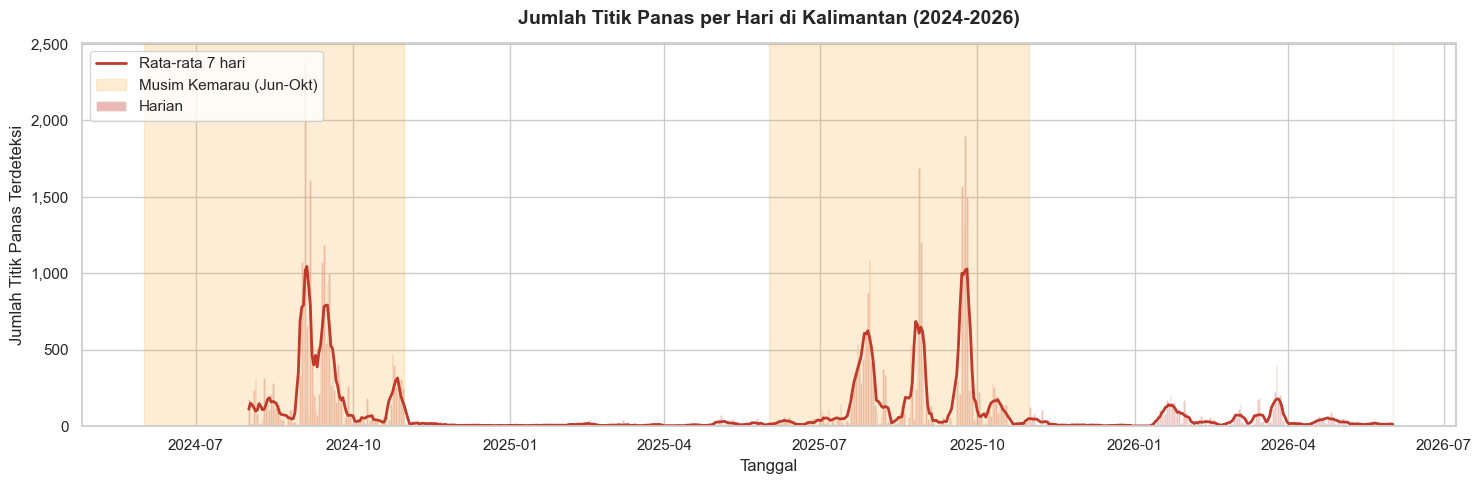

In [27]:
print("\n[4.1] Visualisasi tren harian dan musiman")

daily_counts = df_master.groupby('date_local').size().rename('count')
rolling_7 = daily_counts.rolling(7, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(daily_counts.index, daily_counts.values, color=PALETTE_RED, alpha=0.35, width=1, label='Harian')
ax.plot(rolling_7.index, rolling_7.values, color=PALETTE_RED, linewidth=2, label='Rata-rata 7 hari')

for year in [2024, 2025, 2026]:
    start = pd.to_datetime(f'{year}-06-01')
    end = pd.to_datetime(f'{year}-10-31')
    if start <= daily_counts.index.max():
        ax.axvspan(start, min(end, daily_counts.index.max()), color=PALETTE_GOLD, alpha=0.18,
                   label='Musim Kemarau (Jun-Okt)' if year == 2024 else None)

ax.set_title('Jumlah Titik Panas per Hari di Kalimantan (2024-2026)', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Titik Panas Terdeteksi')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{fig_dir}/A1_tren_harian.png', dpi=150, bbox_inches='tight')
plt.show()

[4.1b] Visualisasi total titik panas per bulan


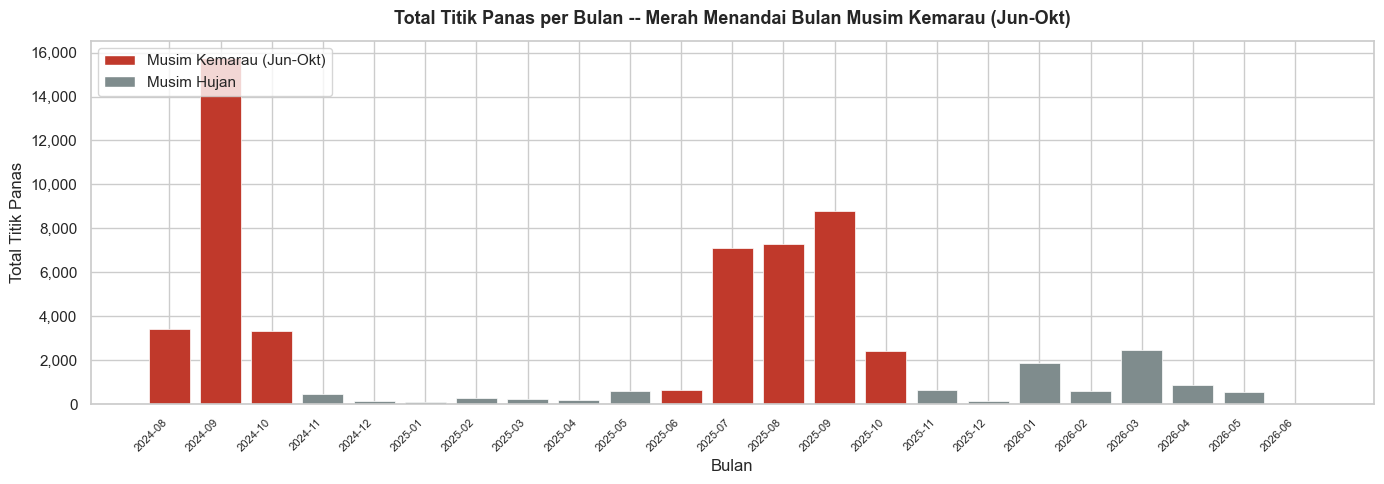

In [28]:
print("[4.1b] Visualisasi total titik panas per bulan")

from matplotlib.patches import Patch

df_master['year_month'] = df_master['date_local'].dt.to_period('M')
monthly = df_master.groupby('year_month').size().reset_index(name='count')
monthly['label'] = monthly['year_month'].astype(str)
monthly_months = pd.PeriodIndex(monthly['year_month']).month

colors_bar = [PALETTE_RED if m in [6,7,8,9,10] else '#7F8C8D' for m in monthly_months]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(monthly)), monthly['count'], color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['label'], rotation=45, ha='right', fontsize=8)
ax.set_title('Total Titik Panas per Bulan -- Merah Menandai Bulan Musim Kemarau (Jun-Okt)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Titik Panas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
legend_elements = [Patch(facecolor=PALETTE_RED, label='Musim Kemarau (Jun-Okt)'),
                   Patch(facecolor='#7F8C8D', label='Musim Hujan')]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.savefig(f'{fig_dir}/A1b_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

[4.1c] Visualisasi deteksi siang vs malam per bulan


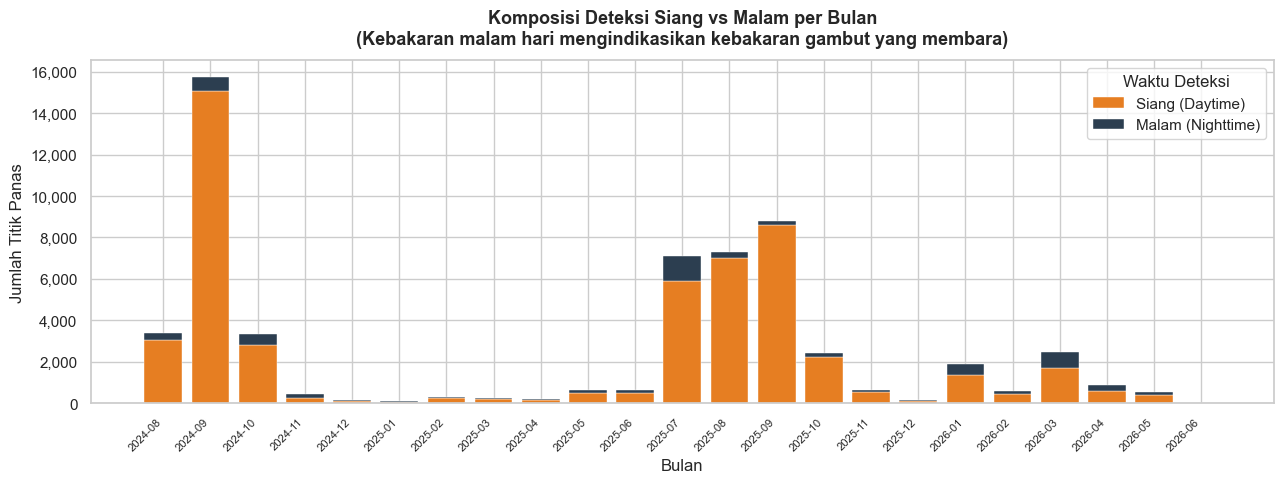

In [29]:
print("[4.1c] Visualisasi deteksi siang vs malam per bulan")

dn_counts = df_master.groupby([pd.Grouper(key='date_local', freq='ME'), 'daynight']).size().unstack(fill_value=0)
dn_counts.index = dn_counts.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(dn_counts))
color_map = {'D': '#E67E22', 'N': '#2C3E50'}
label_map = {'D': 'Siang (Daytime)', 'N': 'Malam (Nighttime)'}

for col in dn_counts.columns:
    ax.bar(range(len(dn_counts)), dn_counts[col], bottom=bottom,
           color=color_map.get(col, 'gray'), label=label_map.get(col, col), edgecolor='white', linewidth=0.3)
    bottom += dn_counts[col].values

ax.set_xticks(range(len(dn_counts)))
ax.set_xticklabels(dn_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Komposisi Deteksi Siang vs Malam per Bulan\n(Kebakaran malam hari mengindikasikan kebakaran gambut yang membara)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Titik Panas')
ax.legend(title='Waktu Deteksi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{fig_dir}/A2_siang_malam.png', dpi=150, bbox_inches='tight')
plt.show()

[4.1d] Perbandingan tren tahunan (Year-over-Year)


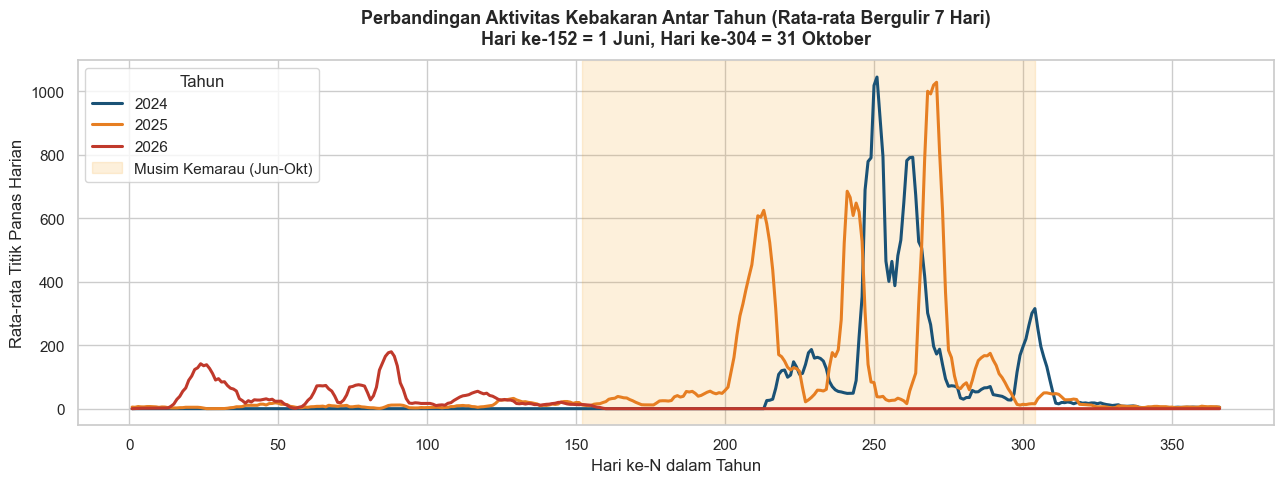

In [30]:
print("[4.1d] Perbandingan tren tahunan (Year-over-Year)")

df_master['day_of_year'] = df_master['date_local'].dt.dayofyear
df_master['year'] = df_master['date_local'].dt.year
yoy_counts = df_master.groupby(['year', 'day_of_year']).size().unstack(level=0, fill_value=0)
yoy_smooth = yoy_counts.rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
color_map_year = {2024: '#1A5276', 2025: '#E67E22', 2026: '#C0392B'}
for col in yoy_smooth.columns:
    if col in color_map_year:
        ax.plot(yoy_smooth.index, yoy_smooth[col], label=str(col),
                color=color_map_year[col], linewidth=2.2)

ax.axvspan(152, 304, color=PALETTE_GOLD, alpha=0.15, label='Musim Kemarau (Jun-Okt)')
ax.set_title('Perbandingan Aktivitas Kebakaran Antar Tahun (Rata-rata Bergulir 7 Hari)\nHari ke-152 = 1 Juni, Hari ke-304 = 31 Oktober', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hari ke-N dalam Tahun')
ax.set_ylabel('Rata-rata Titik Panas Harian')
ax.legend(title='Tahun', loc='upper left')
plt.tight_layout()
plt.savefig(f'{fig_dir}/A4_perbandingan_tahunan.png', dpi=150, bbox_inches='tight')
plt.show()

## Modul B: Analisis Spasial dan Keterpaparan Infrastruktur
Modul ini menunjukkan provinsi mana yang paling banyak mengalami kebakaran, dan seberapa dekat
titik api dengan sekolah. Ini menjawab: di mana ancaman terbesar dan siapa yang paling rentan?


[4.2] Visualisasi distribusi spasial dan paparan sekolah


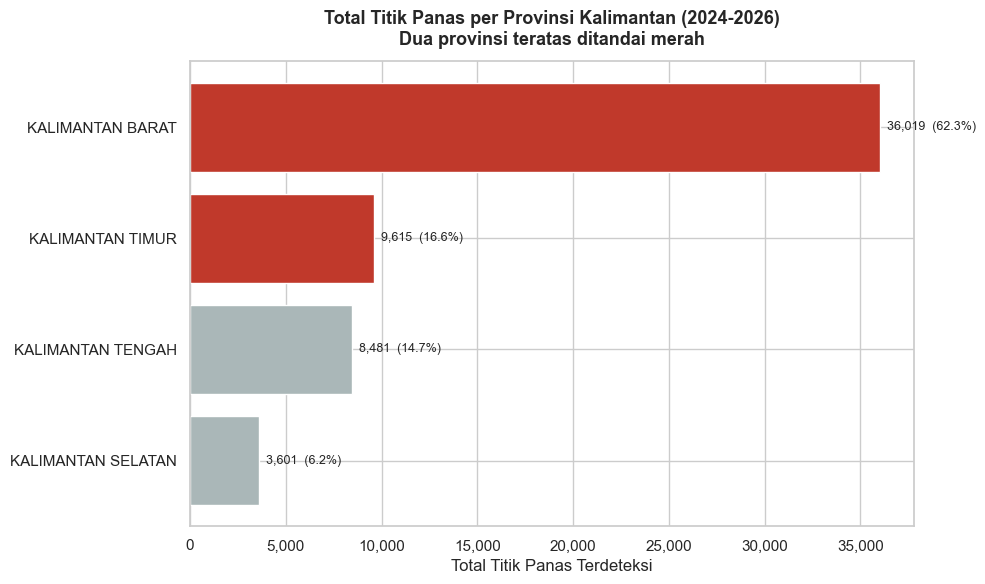

In [31]:
print("\n[4.2] Visualisasi distribusi spasial dan paparan sekolah")

prov_counts = df_master['province_name'].value_counts()
prov_pct = (prov_counts / len(df_master) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
colors_b = [PALETTE_RED if i < 2 else '#AAB7B8' for i in range(len(prov_counts))]
ax.barh(prov_counts.index[::-1], prov_counts.values[::-1], color=colors_b[::-1], edgecolor='white')

for i, (v, pct) in enumerate(zip(prov_counts.values[::-1], prov_pct.values[::-1])):
    ax.text(v + max(prov_counts)*0.01, i, f"{v:,}  ({pct}%)", va='center', fontsize=9)

ax.set_title('Total Titik Panas per Provinsi Kalimantan (2024-2026)\nDua provinsi teratas ditandai merah', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Titik Panas Terdeteksi')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{fig_dir}/B1_jumlah_provinsi.png', dpi=150, bbox_inches='tight')
plt.show()

[4.2b] Distribusi jarak kebakaran ke sekolah terdekat dengan kurva kumulatif


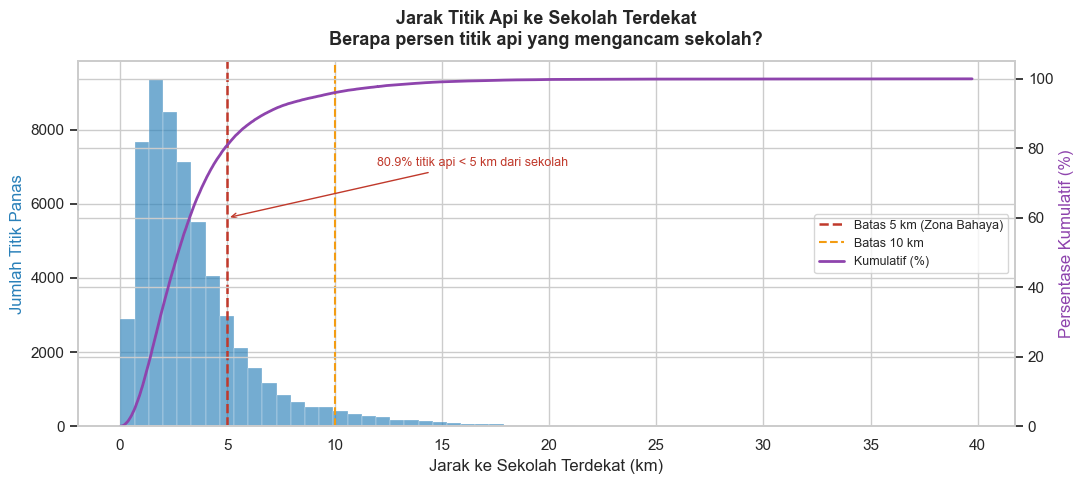

In [32]:
print("[4.2b] Distribusi jarak kebakaran ke sekolah terdekat dengan kurva kumulatif")

dist_data = df_master['dist_nearest_school_km'].dropna()
dist_data_clip = dist_data.clip(upper=50)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

n, bins, patches = ax1.hist(dist_data_clip, bins=60, color=PALETTE_BLUE, alpha=0.65, edgecolor='white', linewidth=0.3)
sorted_dist = np.sort(dist_data)
cdf = np.arange(1, len(sorted_dist)+1) / len(sorted_dist) * 100
ax2.plot(sorted_dist[sorted_dist <= 50], cdf[sorted_dist <= 50], color='#8E44AD', linewidth=2, label='Kumulatif (%)')

ax1.axvline(5, color=PALETTE_RED, linestyle='--', linewidth=1.8, label='Batas 5 km (Zona Bahaya)')
ax1.axvline(10, color=PALETTE_GOLD, linestyle='--', linewidth=1.5, label='Batas 10 km')

pct_5km = (dist_data <= 5).mean() * 100
ax1.annotate(f'{pct_5km:.1f}% titik api < 5 km dari sekolah', xy=(5, n.max()*0.6),
             xytext=(12, n.max()*0.75), fontsize=9, color=PALETTE_RED,
             arrowprops=dict(arrowstyle='->', color=PALETTE_RED))

ax1.set_title('Jarak Titik Api ke Sekolah Terdekat\nBerapa persen titik api yang mengancam sekolah?', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Jarak ke Sekolah Terdekat (km)')
ax1.set_ylabel('Jumlah Titik Panas', color=PALETTE_BLUE)
ax2.set_ylabel('Persentase Kumulatif (%)', color='#8E44AD')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{fig_dir}/B7_paparan_sekolah.png', dpi=150, bbox_inches='tight')
plt.show()

## Modul C: Distribusi Intensitas Api (FRP)
Fire Radiative Power (FRP) mengukur seberapa besar energi yang dikeluarkan oleh api dalam megawatt.
Nilai yang tinggi menandakan api yang besar dan sulit dipadamkan. Distribusinya sangat condong ke kanan,
artinya sebagian besar kebakaran kecil tetapi ada segelintir yang sangat ekstrem dan berbahaya.


[4.3] Visualisasi distribusi dan perbandingan intensitas FRP


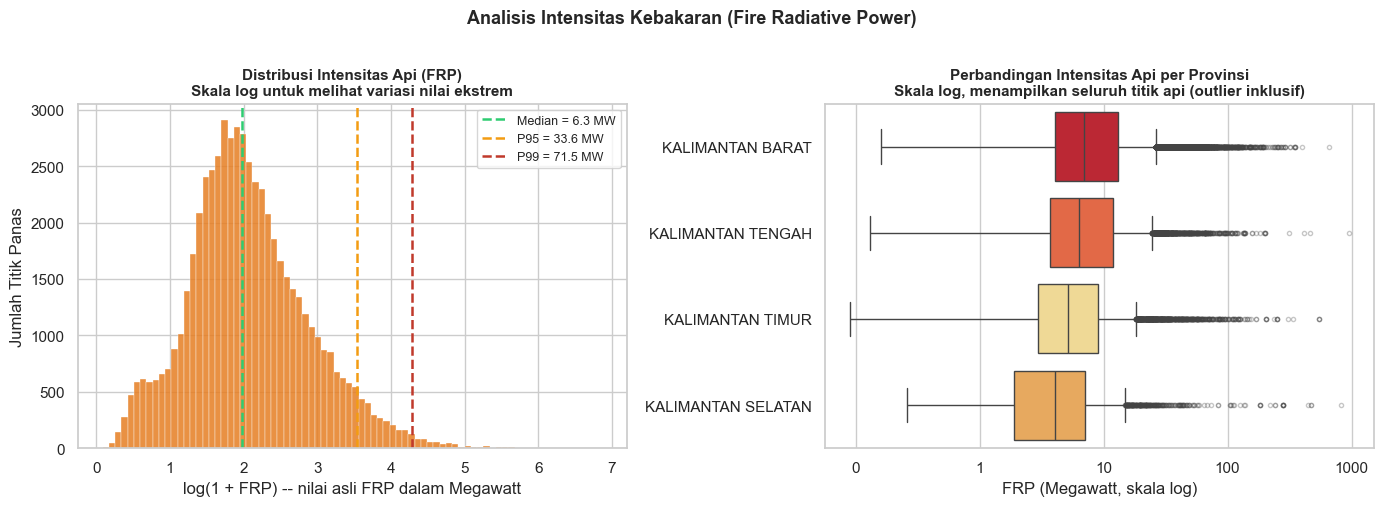

In [33]:
print("\n[4.3] Visualisasi distribusi dan perbandingan intensitas FRP")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(np.log1p(df_master['frp']), bins=80, color='#E67E22', edgecolor='white', linewidth=0.3, alpha=0.85)
p50 = np.log1p(df_master['frp'].quantile(0.50))
p95 = np.log1p(df_master['frp'].quantile(0.95))
p99 = np.log1p(df_master['frp'].quantile(0.99))
ax.axvline(p50, color='#2ECC71', linestyle='--', linewidth=1.8, label=f'Median = {df_master["frp"].median():.1f} MW')
ax.axvline(p95, color=PALETTE_GOLD, linestyle='--', linewidth=1.8, label=f'P95 = {df_master["frp"].quantile(0.95):.1f} MW')
ax.axvline(p99, color=PALETTE_RED, linestyle='--', linewidth=1.8, label=f'P99 = {df_master["frp"].quantile(0.99):.1f} MW')
ax.set_title('Distribusi Intensitas Api (FRP)\nSkala log untuk melihat variasi nilai ekstrem', fontsize=11, fontweight='bold')
ax.set_xlabel('log(1 + FRP) -- nilai asli FRP dalam Megawatt')
ax.set_ylabel('Jumlah Titik Panas')
ax.legend(fontsize=9)

ax = axes[1]
order = df_master.groupby('province_name')['frp'].median().sort_values(ascending=False).index
sns.boxplot(data=df_master, x='frp', y='province_name', order=order,
            hue='province_name', showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.3), palette='YlOrRd_r', legend=False, ax=ax)
ax.set_xscale('log')
ax.set_title('Perbandingan Intensitas Api per Provinsi\nSkala log, menampilkan seluruh titik api (outlier inklusif)', fontsize=11, fontweight='bold')
ax.set_xlabel('FRP (Megawatt, skala log)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

plt.suptitle('Analisis Intensitas Kebakaran (Fire Radiative Power)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{fig_dir}/C_distribusi_frp.png', dpi=150, bbox_inches='tight')
plt.show()

[4.3b] Proporsi tingkat keparahan kebakaran (FRP Tier) -- Donut Chart


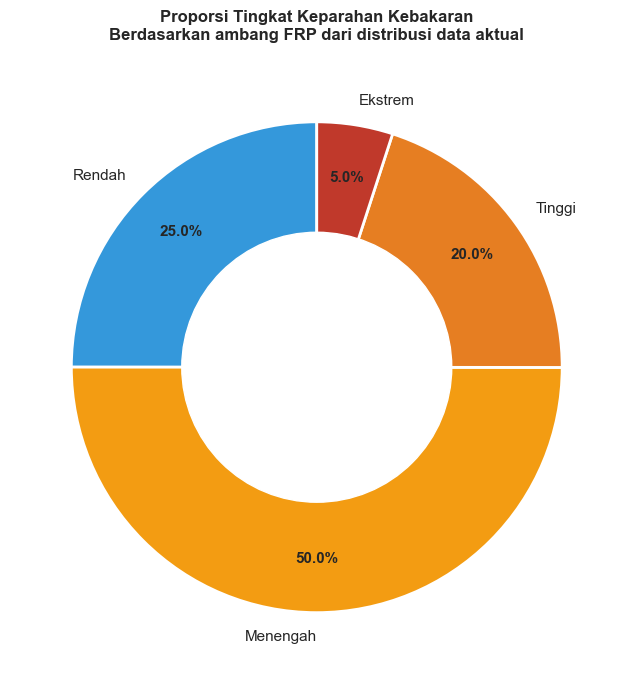

In [34]:
print("[4.3b] Proporsi tingkat keparahan kebakaran (FRP Tier) -- Donut Chart")

if 'frp_tier' in df_master.columns:
    tier_order = ['Rendah', 'Menengah', 'Tinggi', 'Ekstrem']
    tier_counts = df_master['frp_tier'].value_counts().reindex(tier_order, fill_value=0)
    tier_pct = tier_counts / tier_counts.sum() * 100
    colors_tier = ['#3498DB', '#F39C12', '#E67E22', '#C0392B']

    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
        colors=colors_tier, startangle=90, pctdistance=0.78,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight('bold')
    ax.set_title('Proporsi Tingkat Keparahan Kebakaran\nBerdasarkan ambang FRP dari distribusi data aktual', fontsize=12, fontweight='bold', pad=15)
    centre_circle = plt.Circle((0, 0), 0.55, fc='white')
    ax.add_artist(centre_circle)
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/C2_frp_tier.png', dpi=150, bbox_inches='tight')
    plt.show()

## Modul D: Hubungan Curah Hujan dengan Kemunculan Kebakaran
Modul ini memvisualisasikan hubungan antara cuaca dan jumlah titik api.
Jika korelasinya kuat, artinya data cuaca bisa digunakan sebagai sinyal peringatan dini sebelum satelit mendeteksi api.


[4.4] Visualisasi korelasi iklim dan kebakaran


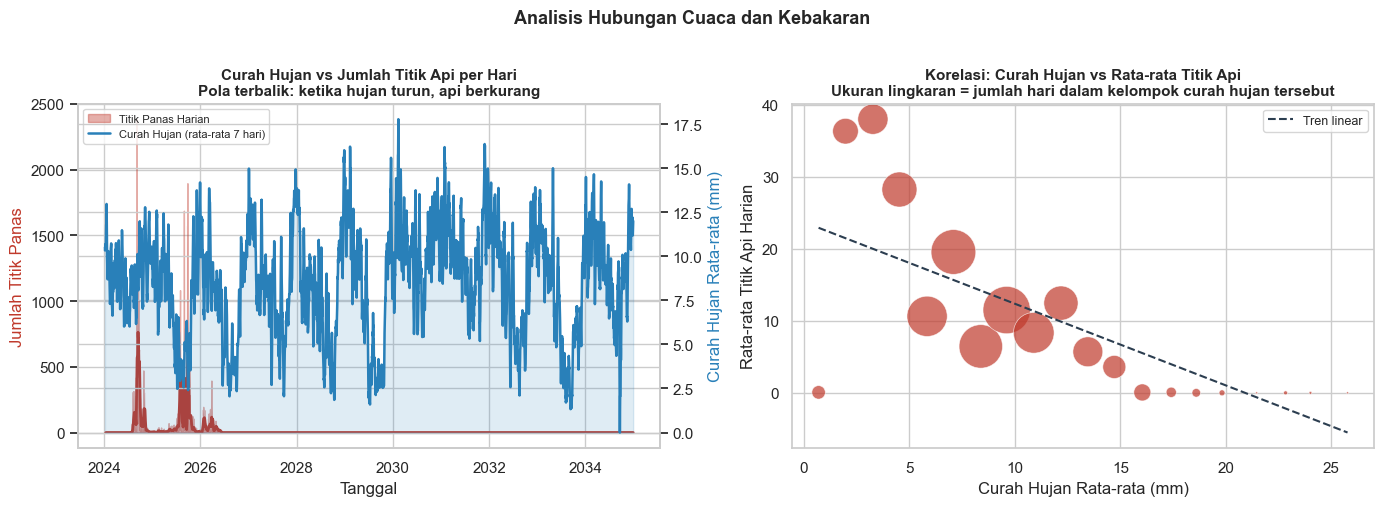

In [35]:
print("\n[4.4] Visualisasi korelasi iklim dan kebakaran")

daily_climate = df_fusion.groupby('date').agg(
    RR=('RR', 'mean'),
    Tavg=('Tavg', 'mean'),
    hotspot_count=('hotspot_count', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.fill_between(daily_climate['date'], daily_climate['hotspot_count'], color=PALETTE_RED, alpha=0.4, label='Titik Panas Harian')
ax1.plot(daily_climate['date'], daily_climate['hotspot_count'].rolling(14).mean(), color=PALETTE_RED, linewidth=2)
rain_smooth = daily_climate['RR'].rolling(7).mean()
ax2.plot(daily_climate['date'], rain_smooth, color=PALETTE_BLUE, linewidth=1.8, label='Curah Hujan (rata-rata 7 hari)')
ax2.fill_between(daily_climate['date'], rain_smooth, alpha=0.15, color=PALETTE_BLUE)
ax1.set_ylabel('Jumlah Titik Panas', color=PALETTE_RED)
ax2.set_ylabel('Curah Hujan Rata-rata (mm)', color=PALETTE_BLUE)
ax1.set_title('Curah Hujan vs Jumlah Titik Api per Hari\nPola terbalik: ketika hujan turun, api berkurang', fontsize=11, fontweight='bold')
ax1.set_xlabel('Tanggal')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)

ax = axes[1]
valid = daily_climate[['RR', 'hotspot_count']].dropna()
valid['rain_bin'] = pd.cut(valid['RR'], bins=20)
scatter_data = valid.groupby('rain_bin', observed=True).agg(
    mean_rain=('RR', 'mean'),
    mean_hotspot=('hotspot_count', 'mean'),
    count=('hotspot_count', 'size')
).reset_index().dropna()

ax.scatter(scatter_data['mean_rain'], scatter_data['mean_hotspot'],
           s=scatter_data['count']*2, color=PALETTE_RED, alpha=0.7, edgecolors='white', linewidth=0.5)
if len(scatter_data) > 1:
    z = np.polyfit(scatter_data['mean_rain'], scatter_data['mean_hotspot'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(scatter_data['mean_rain'].min(), scatter_data['mean_rain'].max(), 100)
    ax.plot(x_line, p(x_line), color='#2C3E50', linestyle='--', linewidth=1.5, label='Tren linear')
ax.set_title('Korelasi: Curah Hujan vs Rata-rata Titik Api\nUkuran lingkaran = jumlah hari dalam kelompok curah hujan tersebut', fontsize=11, fontweight='bold')
ax.set_xlabel('Curah Hujan Rata-rata (mm)')
ax.set_ylabel('Rata-rata Titik Api Harian')
ax.legend(fontsize=9)

plt.suptitle('Analisis Hubungan Cuaca dan Kebakaran', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{fig_dir}/D1_korelasi_iklim.png', dpi=150, bbox_inches='tight')
plt.show()

## Penyusunan Laporan Wawasan Temuan
Merangkum seluruh temuan utama dari visualisasi di atas ke dalam laporan ringkas berformat Markdown.

In [36]:
prov_counts = df_master['province_name'].value_counts()
top_prov = prov_counts.index[0]
top_prov_pct = (prov_counts.iloc[0] / len(df_master)) * 100
dn_pct = df_master['daynight'].value_counts(normalize=True) * 100
danger_zone = (df_master['dist_nearest_school_km'] <= 5).sum()
danger_pct = (danger_zone / len(df_master)) * 100

with open('../outputs/eda_insights.md', 'w', encoding='utf-8') as f:
    f.write("# Laporan Analisis Data Eksploratif (EDA) FIRELINE\n\n")
    f.write("## 1. Pola Waktu\n")
    f.write(f"- Total titik panas: {len(df_master):,}\n")
    f.write(f"- Dampak musim kemarau: {df_master['is_dry_season'].mean()*100:.1f}% kebakaran terjadi antara Juni dan Oktober.\n")
    if 'N' in dn_pct:
        f.write(f"- Deteksi malam hari: {dn_pct.get('N', 0):.1f}% deteksi terjadi di malam hari.\n")
    f.write("\n## 2. Analisis Spasial dan Kerentanan\n")
    f.write(f"- Provinsi paling terdampak: {top_prov} menyumbang {top_prov_pct:.1f}% dari seluruh deteksi.\n")
    f.write(f"- Paparan sekolah: {danger_zone:,} titik api ({danger_pct:.1f}%) berada dalam jarak 5 km dari sekolah.\n")
    f.write("\n## 3. Intensitas Kebakaran\n")
    f.write(f"- Nilai tengah FRP: {df_master['frp'].median():.1f} MW. Persentil 95 = {df_master['frp'].quantile(0.95):.1f} MW.\n")

print("Laporan wawasan berhasil disimpan di ../outputs/eda_insights.md")
elapsed = time.time() - start_time
print(f"FASE 4 SELESAI DALAM {elapsed:.1f} DETIK")

Laporan wawasan berhasil disimpan di ../outputs/eda_insights.md
FASE 4 SELESAI DALAM 6.2 DETIK
